### Packages needed
1. pyUNICORN - for RQA and RP
2. matplotlib - plotting the data

In [3]:
from pyunicorn.timeseries import RecurrenceNetwork
from pyunicorn.timeseries import RecurrencePlot
from pyunicorn.core import Network
import sys,os, shutil
import networkx as nx
import pylab
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import subprocess as sb
import glob
%matplotlib inline
plt.rcParams['axes.linewidth'] = 2

In [5]:
d=10
e = 1.6
def show_graph(adjacency_matrix):
    rows, cols = np.where(adjacency_matrix == 1)
    edges = zip(rows.tolist(), cols.tolist())
    gr = nx.Graph()
    gr.add_edges_from(edges)
    nx.draw(gr, node_size=0.5, edge_color='r', width=0.01, with_labels=False)
    plt.show()

def open_file(rootfilename, eps, length):
    surro_DET = []
    surro_LAM = []
    for i in range(1,10):
        file = rootfilename + "_00" + str(i) 
        print(file)
        data = np.loadtxt(file) 
        surro_rp_data = RecurrencePlot(data, metric="euclidean",dim=d, tau=1, threshold=eps, normalize=True)
        RRsur = surro_rp_data.recurrence_rate()
        DETsur = surro_rp_data.determinism(l_min=length)
        LAMsur = surro_rp_data.laminarity(v_min=length)
        surro_DET.append(DETsur)
        surro_LAM.append(LAMsur)
        data = []
    for j in range (10, 40):
        file = rootfilename + "_0" + str(j)
        print(file)
        data = np.loadtxt(file) 
        surro_rp_data = RecurrencePlot(data, metric="euclidean", dim=d, tau=1,threshold=eps, normalize=True)
        RRsur = surro_rp_data.recurrence_rate()
        DETsur = surro_rp_data.determinism(l_min=length)
        LAMsur = surro_rp_data.laminarity(v_min=length)
        surro_DET.append(DETsur)
        surro_LAM.append(LAMsur)
        data = []      
    return surro_DET, surro_LAM


In [6]:
def lcurve(p):
    fig1, ax = plt.subplots(1)
    j =  np.loadtxt("files/{}".format(p))
    ax.plot(j)
    np.savetxt("s/qp", j)
    fig1.savefig('n/LC/{}.png'.format(p))
    return j

def RP_RN(l, i):
    qpo_rp = RecurrencePlot(l, dim=3, tau=9, metric = "euclidean", threshold=e, normalize=True)
    #qpo_rp_rn = RecurrenceNetwork(l, dim=5, tau=1,metric = "euclidean", threshold=3, normalize=True)
    pylab.matshow(qpo_rp.recurrence_matrix())
    pylab.xlabel("$n$")
    pylab.ylabel("$n$")
    pylab.title("Recurrence plot for {}".format(i))
    pylab.savefig('n/RP/{}'.format(i))
    RRqpo = qpo_rp.recurrence_rate()
    DETqpo = qpo_rp.determinism(l_min=2)
    LAMqpo = qpo_rp.laminarity(v_min=2)
    ENTR = qpo_rp.diag_entropy(l_min=2, resampled_dist=None)
    f = open("data", "a")
    f.write("RQA for {}\n Determinism:{}, Recurrence rate:{}, Laminarity:{}, ENT: {} \n".format(i, DETqpo, RRqpo,LAMqpo,ENTR))
    f.close()
    #show_graph(qpo_rp_rn.adjacency)
    return DETqpo


def sur_test(l, m):
    os.system("./files/surrogates files/{} -n40 -S -o -V0".format(m))
    a, b = open_file("files/{}_surr".format(m), e, 2)
    fig2, axs = plt.subplots(1)
    fig2.suptitle('Surrogate test for {}'.format(i))
    axs.plot(a, label = 'DET of the each surrogate data')
    c, d = RP_RN(l, m)
    axs.axhline(y = c, color = 'r', linestyle = '-', label = 'DET of the original data' )
    axs.legend(loc='lower right')
    axs.set_xlabel("Surrogate data set no. ")
    axs.set_ylabel("DET")
    fig2.savefig('n/surro/{}.png'.format(m))

In [7]:
data1 = np.loadtxt("psei.csv", delimiter =',', usecols =(1) , skiprows=1)*1000
data2 = np.loadtxt("psei.csv", delimiter =',', usecols =(2) , skiprows=1)

In [8]:
data = data1 + data2

In [9]:
data

array([6528.79, 6613.85, 7142.96, 7272.65, 6897.54, 6619.09, 6411.91,
       6433.1 , 6700.49, 6903.53, 6944.71, 6646.44, 6450.04, 6223.73,
       5973.78, 6321.24, 6175.25, 6591.47, 6468.07, 6477.36, 6625.08,
       6499.68, 6556.2 , 6793.25, 6566.39, 6780.78, 6153.43, 5741.07,
       6583.65, 6315.93, 6155.43, 6774.68, 6731.25, 7203.47, 7311.01,
       7361.65, 7122.63, 7200.88, 7054.7 , 6952.88, 6855.44, 6270.23,
       6901.91, 6628.49, 6370.87, 6443.09, 6794.86, 6612.62, 7139.71,
       6791.46, 6324.  , 5864.23, 5884.18, 5928.45, 6207.72, 5838.84,
       5700.71, 5321.23, 6787.91, 7200.79, 7815.26, 7738.96, 7977.12,
       7779.07, 7979.66, 8045.8 , 7999.71, 7970.02, 7952.72, 7920.93,
       7705.49, 8007.48, 7466.02, 7367.85, 7140.29, 7276.82, 7855.71,
       7672.  , 7193.68, 7497.17, 7819.25, 7979.83, 8475.29, 8764.01,
       8558.42, 8254.03, 8365.26, 8171.43, 7958.57, 8018.05, 7843.16,
       7837.12, 7661.01, 7311.72, 7212.09, 7229.66, 6840.64, 6781.2 ,
       7404.8 , 7629

In [5]:
np.savetxt("stocks", data)

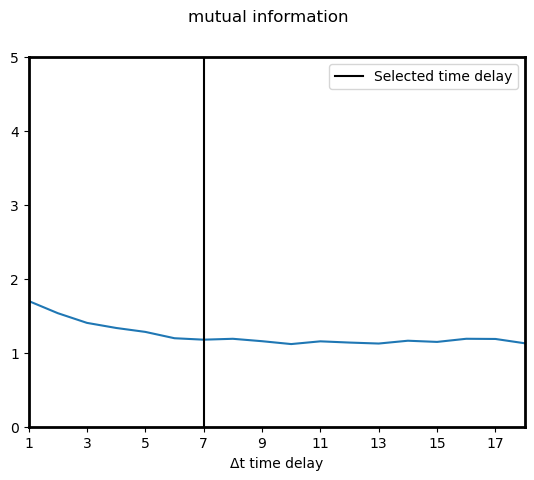

In [10]:
m_site1 = np.loadtxt("files/mutual_stocks", delimiter =' ', usecols =(1) , skiprows=0)

fig2, axs = plt.subplots(1)
fig2.suptitle("mutual information")
axs.plot(m_site1)
plt.axvline(x = 7, color = 'black', label = 'Selected time delay')
plt.xticks(range(1,21,2))
axs.set_xlim([1, 18])
axs.set_ylim([0, 5])
plt.xlabel("Δt time delay")
plt.legend()
plt.show()

/tmp/ipykernel_11275/2346709959.py:13: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  ax.set_ylim([0, 5])


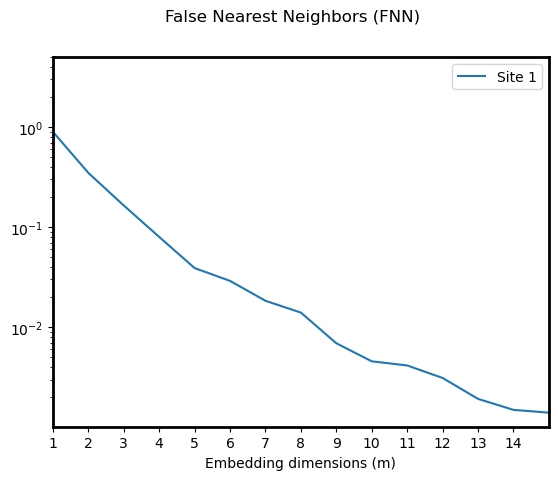

In [11]:
m1 = np.loadtxt("files/stocks.fnn", usecols=1)
d1 = np.loadtxt("files/stocks.fnn", usecols=0)

fig2, ax = plt.subplots(1)
fig2.suptitle("False Nearest Neighbors (FNN)")
ax.plot(d1, m1/d1,label='Site 1')

ax.set_yscale("log")
plt.xticks(range(1,15,1))
plt.xlabel("Embedding dimensions (m)")
plt.legend()
ax.set_xlim([1, 15])
ax.set_ylim([0, 5])
# ax.set_ylim([0, 0.35])
plt.show()

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...


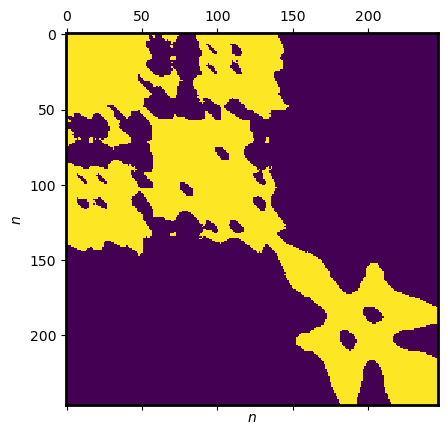

In [12]:
qpo_rp = RecurrencePlot(data, dim=d, tau=1, metric = "euclidean", threshold=1.6, normalize=True)
pylab.matshow(qpo_rp.recurrence_matrix())
pylab.xlabel("$n$")
pylab.ylabel("$n$")
RRqpo = qpo_rp.recurrence_rate()
DETqpo = qpo_rp.determinism(l_min=2)
LAMqpo = qpo_rp.laminarity(v_min=2)
ENTR = qpo_rp.diag_entropy(l_min=2, resampled_dist=None)

In [13]:
DETqpo

0.9978654198002653

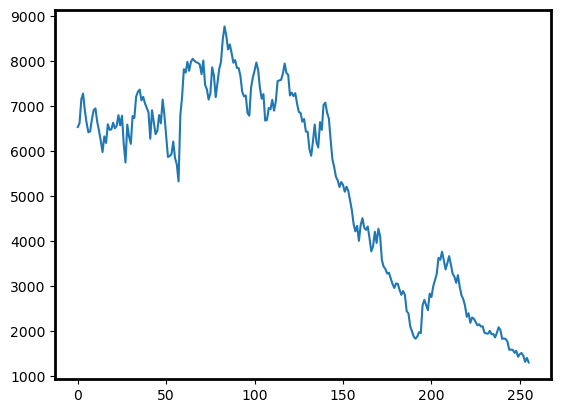

In [13]:
fig1, ax = plt.subplots(1)
ax.plot(data)

files/stocks_surr_001
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
files/stocks_surr_002
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
files/stocks_surr_003
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
files/stocks_surr_004
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
files/stocks_surr_005
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
files/stocks_surr_006
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
files/stocks_surr_007
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
files/stocks_surr_008
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
files/stocks_surr_009
Calculating recurrence plot at fixed thres

Text(0, 0.5, 'DET')

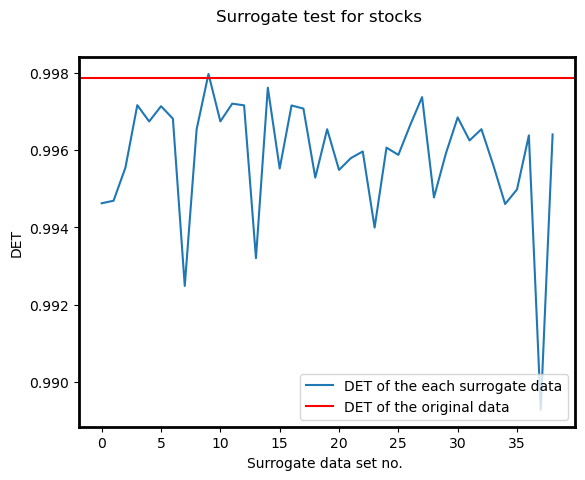

In [14]:
a, b = open_file("files/stocks_surr", e, 2)
fig2, axs = plt.subplots(1)
fig2.suptitle('Surrogate test for stocks')
axs.plot(a, label = 'DET of the each surrogate data')
axs.axhline(y = DETqpo, color = 'r', linestyle = '-', label = 'DET of the original data' )
axs.legend(loc='lower right')
axs.set_xlabel("Surrogate data set no. ")
axs.set_ylabel("DET")

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
files/site5_surr_001
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
files/site5_surr_002
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
files/site5_surr_003
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
files/site5_surr_004
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
files/site5_surr_005
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
files/site5_surr_006
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
files/site5_surr_007
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
files/site5_surr_008
Calculating recurrence plot at fixed threshold...
Calculating the euclid

TypeError: cannot unpack non-iterable numpy.float64 object

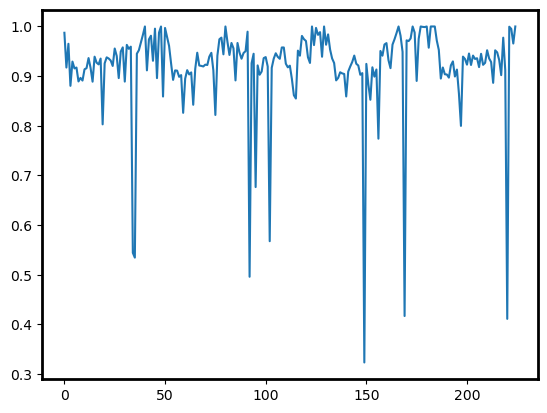

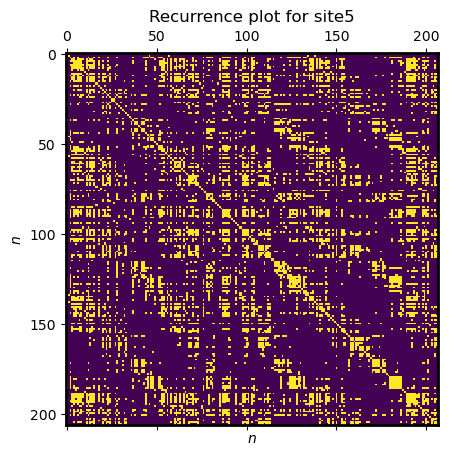

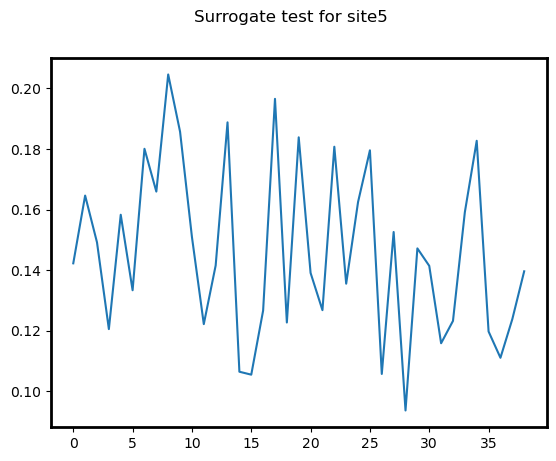

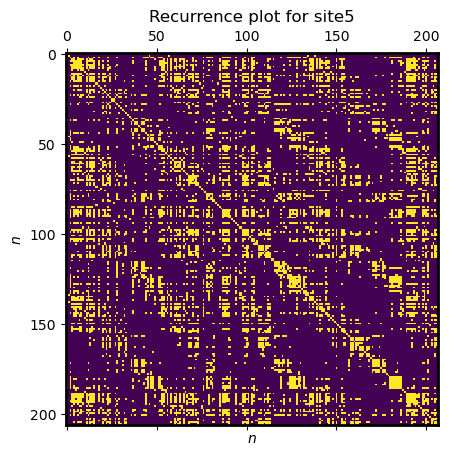

In [8]:

obsid = {'site1', 'site2','site3','site4', 'site5'}
s = open("data", "w")
s.write("")

for i in obsid:
    s = lcurve(i)
    RP_RN(s, i)
    sur_test(s, i)

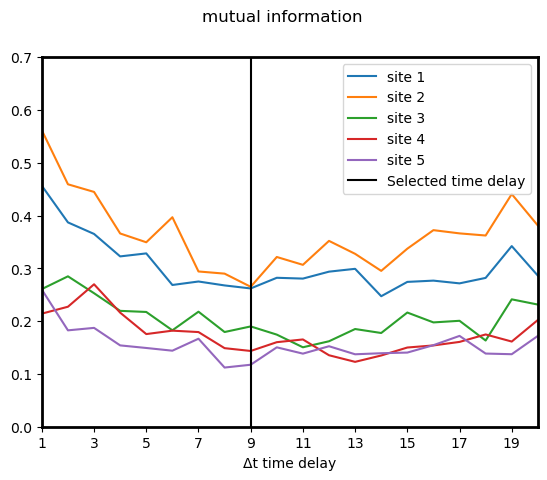

In [5]:
m_site1 = np.loadtxt("files/mutual_site1", delimiter =' ', usecols =(1) , skiprows=0)
m_site2 = np.loadtxt("files/mutual_site2", delimiter =' ', usecols =(1) , skiprows=0)
m_site3 = np.loadtxt("files/mutual_site3", delimiter =' ', usecols =(1) , skiprows=0)
m_site4 = np.loadtxt("files/mutual_site4", delimiter =' ', usecols =(1) , skiprows=0)
m_site5 = np.loadtxt("files/mutual_site5", delimiter =' ', usecols =(1) , skiprows=0)

fig2, axs = plt.subplots(1)
fig2.suptitle("mutual information")
axs.plot(m_site1, label='site 1')
axs.plot(m_site2, label='site 2')
axs.plot(m_site3, label='site 3')
axs.plot(m_site4, label='site 4')
axs.plot(m_site5, label='site 5')
plt.axvline(x = 9, color = 'black', label = 'Selected time delay')
plt.xticks(range(1,21,2))
axs.set_xlim([1, 20])
axs.set_ylim([0, 0.7])
plt.xlabel("Δt time delay")
plt.legend()
plt.show()

/tmp/ipykernel_22705/3812598479.py:23: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  ax.set_ylim([0, 1])


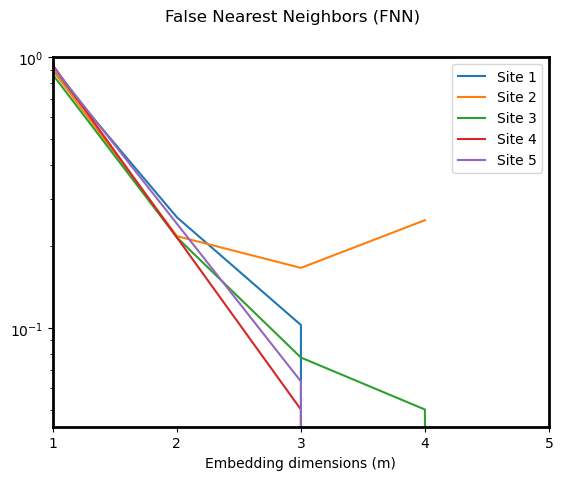

In [6]:
m1 = np.loadtxt("files/site1.fnn", usecols=1)
d1 = np.loadtxt("files/site1.fnn", usecols=0)
m2 = np.loadtxt("files/site2.fnn", usecols=1)
d2 = np.loadtxt("files/site2.fnn", usecols=0)
m3 = np.loadtxt("files/site3.fnn", usecols=1)
d3 = np.loadtxt("files/site3.fnn", usecols=0)
m4 = np.loadtxt("files/site4.fnn", usecols=1)
d4 = np.loadtxt("files/site4.fnn", usecols=0)
m5 = np.loadtxt("files/site5.fnn", usecols=1)
d5 = np.loadtxt("files/site5.fnn", usecols=0)
fig2, ax = plt.subplots(1)
fig2.suptitle("False Nearest Neighbors (FNN)")
ax.plot(d1,m1/d1,label='Site 1')
ax.plot(d2,m2/d2,label='Site 2')
ax.plot(d3,m3/d3,label='Site 3')
ax.plot(d4,m4/d4,label='Site 4')
ax.plot(d5,m5/d5,label='Site 5')
ax.set_yscale("log")
plt.xticks(range(1,6,1))
plt.xlabel("Embedding dimensions (m)")
plt.legend()
ax.set_xlim([1, 5])
ax.set_ylim([0, 1])
# ax.set_ylim([0, 0.35])
plt.show()

In [12]:
x = np.linspace(1,len(m1),len(m1)).astype('int')

In [13]:
x

array([1, 2, 3, 4])